In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import svm
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import recall_score, accuracy_score

# data = "/Users/alexandraantonica/Desktop/RW/final_data.csv"
# df = pd.read_csv(data)

# X = df[['E', 'PEMi', 'Size_KLOC', 'ACT_EFFORT']]
# y = df["categorical_output"]

# # Splitting the data into training and test sets with stratification
# X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

train_data = "/Users/alexandraantonica/Desktop/RW/augmented_data.csv"
train_df = pd.read_csv(train_data)
test_data = "/Users/alexandraantonica/Desktop/RW/normalized_orig_data.csv"
test_df = pd.read_csv(test_data)

X_train, y_train = train_df[['E', 'PEMi', 'Size KLOC', 'ACT_EFFORT']], train_df["categorical_output"]
X_test, y_test = test_df[['E', 'PEMi', 'Size KLOC', 'ACT_EFFORT']], test_df["categorical output"]

In [20]:
# New XGBoost

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

# Encode categorical output
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.fit_transform(y_test)

# Define the grid of hyperparameters to search over
param_grid = {
    'learning_rate': [0.1],
    'max_depth': [3],
    'min_child_weight': [1],
    'subsample': [1.0],
    'colsample_bytree': [0.8],
    'reg_alpha': [1],
    'reg_lambda': [0.1]
}

# Initialize XGBoost classifier
xgb_classifier = XGBClassifier(objective='multi:softmax', num_class=len(set(y_train)))

# Create GridSearchCV object
grid_search = GridSearchCV(xgb_classifier, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Perform grid search on training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Initialize XGBoost classifier with best hyperparameters
best_xgb_classifier = XGBClassifier(objective='multi:softmax', num_class=len(set(y_train)), **best_params)

# Train the model with best hyperparameters on the entire training data
best_xgb_classifier.fit(X_train, y_train)

# Making predictions on the training and test sets with best hyperparameters
y_train_pred_best = best_xgb_classifier.predict(X_train)
y_test_pred_best_xg = best_xgb_classifier.predict(X_test)

# Calculate accuracy and recall with best hyperparameters
train_accuracy_best_xg = accuracy_score(y_train, y_train_pred_best)
test_accuracy_best_xg = accuracy_score(y_test, y_test_pred_best)
train_recall_best_xg = recall_score(y_train, y_train_pred_best, average='macro')
test_recall_best_xg = recall_score(y_test, y_test_pred_best, average='macro')

# Compute confusion matrix with best hyperparameters
conf_matrix_best = confusion_matrix(y_test, y_test_pred_best)

print("Best Hyperparameters:", best_params)
print(f"Training Accuracy with best hyperparameters: {train_accuracy_best_xg:.3f}")
print(f"Test Accuracy with best hyperparameters: {test_accuracy_best_xg:.3f}")
print(f"Training Recall with best hyperparameters: {train_recall_best_xg:.3f}")
print(f"Testing Recall with best hyperparameters: {test_recall_best_xg:.3f}")
print("Confusion matrix with best hyperparameters:")
print(conf_matrix_best)


Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'reg_alpha': 1, 'reg_lambda': 0.1, 'subsample': 1.0}
Training Accuracy with best hyperparameters: 0.624
Test Accuracy with best hyperparameters: 0.816
Training Recall with best hyperparameters: 0.486
Testing Recall with best hyperparameters: 0.836
Confusion matrix with best hyperparameters:
[[10  0  1]
 [ 2 40  8]
 [ 0  3 12]]


In [21]:
# New SVM

from sklearn import svm
from sklearn.model_selection import GridSearchCV
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

# Define the hyperparameter grid to search over
param_grid = {
    'C': [100],  # Regularization parameter
    'kernel': ['rbf'],  # Kernel type
    'gamma': ['scale'],  # Kernel coefficient for 'rbf' and 'poly'
    'degree': [2],  # Degree for 'poly' kernel
}

# Initialize SVM classifier
svm_classifier = svm.SVC()

# Create GridSearchCV object
grid_search = GridSearchCV(svm_classifier, param_grid, cv=5, scoring='accuracy')

# Perform grid search on training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Initialize SVM classifier with best hyperparameters
best_svm_classifier = svm.SVC(**best_params)

# Train the model with best hyperparameters on the entire training data
best_svm_classifier.fit(X_train, y_train)

# Making predictions on the training and test sets with best hyperparameters
y_train_pred_best = best_svm_classifier.predict(X_train)
y_test_pred_best = best_svm_classifier.predict(X_test)

# Calculate accuracy and recall with best hyperparameters
train_accuracy_best = accuracy_score(y_train, y_train_pred_best)
test_accuracy_best = accuracy_score(y_test, y_test_pred_best)
train_recall_best = recall_score(y_train, y_train_pred_best, average='macro')
test_recall_best = recall_score(y_test, y_test_pred_best, average='macro')

# Compute confusion matrix with best hyperparameters
conf_matrix_best = confusion_matrix(y_test, y_test_pred_best)

print("Best Hyperparameters:", best_params)
print(f"Training Accuracy with best hyperparameters: {train_accuracy_best:.3f}")
print(f"Test Accuracy with best hyperparameters: {test_accuracy_best:.3f}")
print(f"Training Recall with best hyperparameters: {train_recall_best:.3f}")
print(f"Testing Recall with best hyperparameters: {test_recall_best:.3f}")
print("Confusion matrix with best hyperparameters:")
print(conf_matrix_best)


Best Hyperparameters: {'C': 100, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Training Accuracy with best hyperparameters: 0.632
Test Accuracy with best hyperparameters: 0.816
Training Recall with best hyperparameters: 0.496
Testing Recall with best hyperparameters: 0.836
Confusion matrix with best hyperparameters:
[[10  0  1]
 [ 2 40  8]
 [ 0  3 12]]


In [22]:
# New Logistic Regression 

# Define regularization strength (smaller values mean stronger regularization)
C = 10

# Training with regularization
logreg_regularized = LogisticRegression(C=C)
logreg_regularized.fit(X_train, y_train)

# Using .score() to calculate the accuracy
train_accuracy_logreg_reg = logreg_regularized.score(X_train, y_train)
test_accuracy_logreg_reg = logreg_regularized.score(X_test, y_test)

# Predictions for calculating recall
y_test_pred_reg = logreg_regularized.predict(X_test)

# Calculate recall
test_recall_logreg_reg = recall_score(y_test, y_test_pred_reg, average='macro')

# Compute confusion matrix
conf_matrix_lr_reg = confusion_matrix(y_test, y_test_pred_reg)

# Print the metrics with regularization
print(f"Training score with regularization: {train_accuracy_logreg_reg:.3f}")
print(f"Test set score with regularization: {test_accuracy_logreg_reg:.3f}")
print(f"Testing Recall with regularization: {test_recall_logreg_reg:.3f}")
print("Confusion Matrix with regularization:") 
print(conf_matrix_lr_reg)


Training score with regularization: 0.586
Test set score with regularization: 0.763
Testing Recall with regularization: 0.654
Confusion Matrix with regularization:
[[ 8  3  0]
 [ 1 45  4]
 [ 0 10  5]]


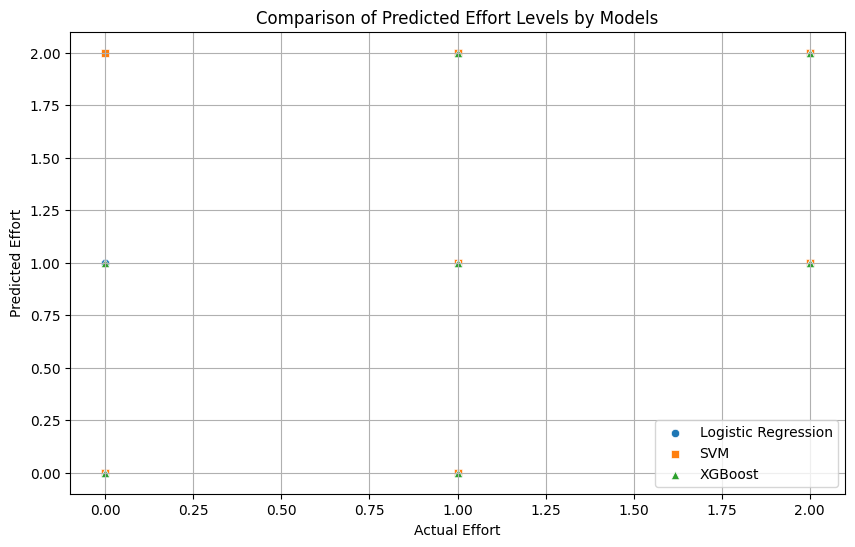

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame or numpy array containing the actual labels and the predicted labels for each model
results = pd.DataFrame({'Actual': y_test,
                        'Logistic Regression': y_test_pred_reg,
                        'SVM': y_test_pred_best,
                        'XGBoost': y_test_pred_best_xg})

# Encode labels if necessary (assuming the labels are already encoded)
encoder = LabelEncoder()
results_encoded = results.apply(encoder.fit_transform)

# Plot scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results, x='Actual', y='Logistic Regression', label='Logistic Regression', marker='o')
sns.scatterplot(data=results, x='Actual', y='SVM', label='SVM', marker='s')
sns.scatterplot(data=results, x='Actual', y='XGBoost', label='XGBoost', marker='^')
plt.xlabel('Actual Effort')
plt.ylabel('Predicted Effort')
plt.title('Comparison of Predicted Effort Levels by Models')
plt.legend()
plt.grid(True)
plt.show()


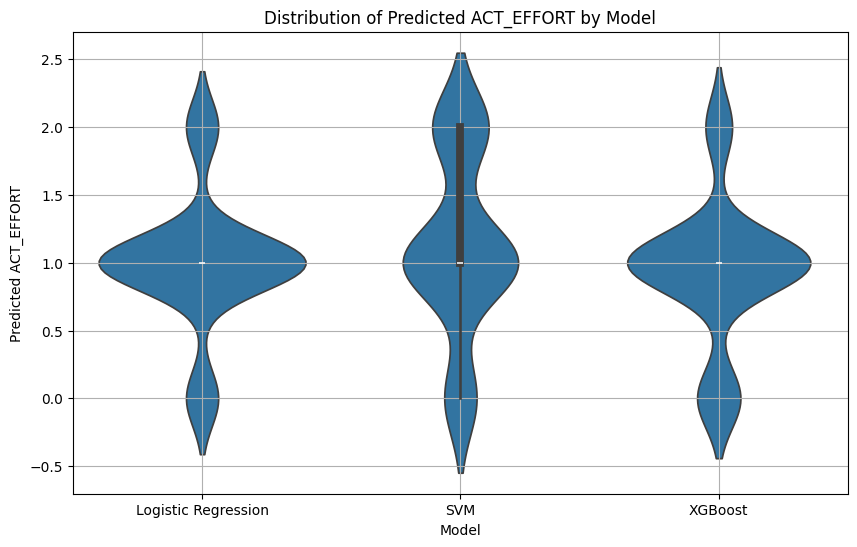

In [15]:
# Create a DataFrame containing the actual ACT_EFFORT values and the predicted ACT_EFFORT values for each model
results = pd.DataFrame({'Actual': y_test,
                        'Logistic Regression': y_test_pred_reg,
                        'SVM': y_test_pred_best,
                        'XGBoost': y_test_pred_best_xg})

# Melt the DataFrame to have 'Model' as a variable
results_melted = results.melt(id_vars='Actual', var_name='Model', value_name='Predicted')

# Plot violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=results_melted, x='Model', y='Predicted')
plt.xlabel('Model')
plt.ylabel('Predicted ACT_EFFORT')
plt.title('Distribution of Predicted ACT_EFFORT by Model')
plt.grid(True)
plt.show()


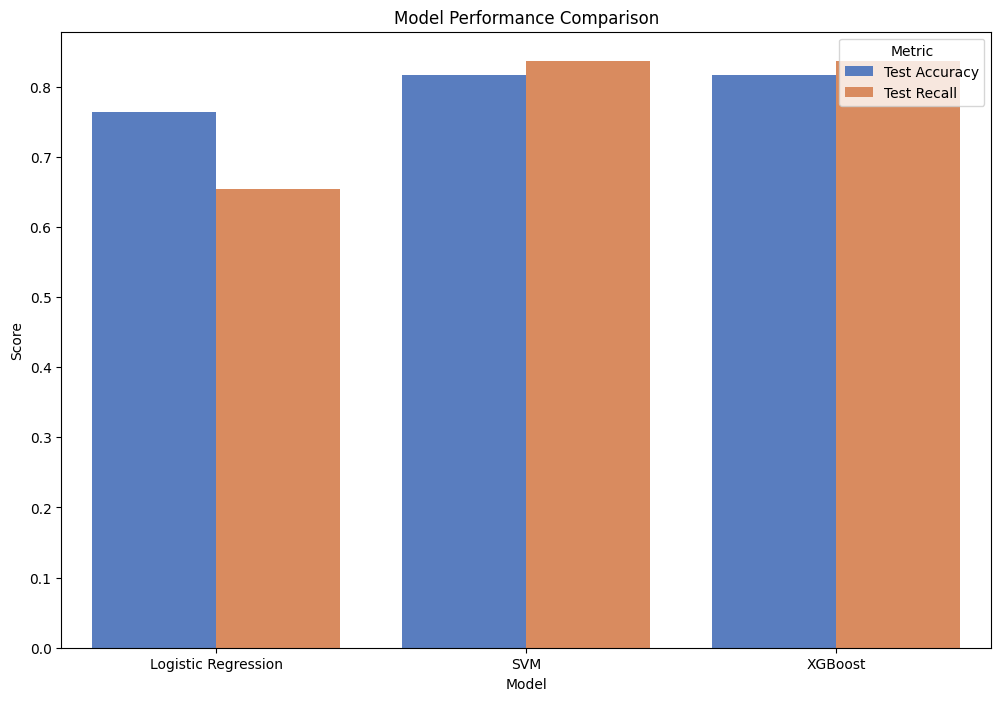

In [27]:
# barplot of metrics

# Create a DataFrame to store the model performances
model_performance = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'XGBoost'],
    'Test Accuracy': [test_accuracy_logreg_reg, test_accuracy_best, test_accuracy_best_xg],
    'Test Recall': [test_recall_logreg_reg, test_recall_best, test_recall_best_xg]
})

# Melt the DataFrame for easier plotting
model_performance_melted = pd.melt(model_performance, id_vars='Model', var_name='Metric', value_name='Score')

# Create bar plots
plt.figure(figsize=(12, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=model_performance_melted, palette='muted')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(title='Metric', loc='upper right')
plt.show()
